# Langkah 1 — Sediakan Folder Projek & Git



*   Cipta folder dengan nama : DKA3223_AMALI1_NABIL
*   Cipta repository di GitHub



# Langkah 2 — Import Library

*   tensor operations (data)
*   neural network module (untuk bina model)


*   dataset & DataLoader (untuk load MNIST & bahagi kepada batch)
*   paparan imej (untuk tunjuk gambar digit)










In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Semak versi PyTorch dan peranti yang digunakan (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


# Langkah 3 — Muat & Semak Dataset MNIST



*   MNIST = dataset digit tulisan tangan 0-9, gambar hitam-putih saiz 28×28 piksel

*   ToTensor() tukar imej (format PIL) kepada tensor PyTorch supaya boleh diproses oleh model

*   train_loader & test_loader akan "suap" data kepada model secara berkumpulan (batch), bukan satu-satu — lebih efisien





Training data: 60000
Testing data: 10000
Image shape: torch.Size([1, 28, 28])
Actual label: 7


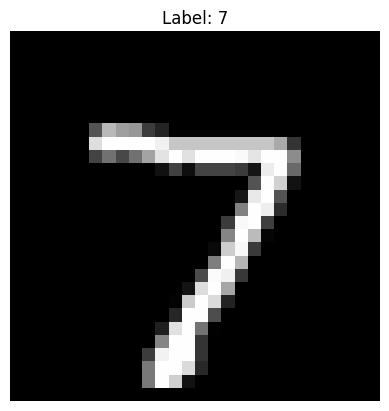

In [17]:
# 3.3.1 - Transform: tukar imej MNIST kepada tensor
transform = transforms.ToTensor()

# 3.3.2 - Muatkan training & testing dataset
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 3.3.3 - Bina DataLoader dengan batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3.3.4 - Papar bilangan data
print("Training data:", len(train_dataset))
print("Testing data:", len(test_dataset))

# 3.3.5 - Ambil satu imej daripada testing dataset & papar
image, label = test_dataset[0]
print("Image shape:", image.shape)
print("Actual label:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

# Langkah 4 — Bina Model ANN



*   ANN (Artificial Neural Network) = model asas, tak faham struktur 2D gambar — kena "flatten" (ratakan) imej 28×28 jadi satu senarai 784 nombor dahulu

*   Guna hidden layer + ReLU (fungsi aktivasi) supaya model boleh belajar corak kompleks

*   Output 10 sebab ada 10 kelas (digit 0-9)





In [18]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)   # input 784 -> hidden layer 128
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)      # hidden layer -> output 10 kelas

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

ann_model = ANN().to(device)
print(ann_model)

# 3.4.4 - Loss function & optimizer
criterion_ann = nn.CrossEntropyLoss()
optimizer_ann = optim.Adam(ann_model.parameters(), lr=0.001)

ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Langkah 5 — Latih & Uji ANN



*   Training loop: model lihat data training berulang kali (2 epoch), setiap kali cuba kurangkan loss (kesilapan)

*   Selepas siap latih, tukar model ke evaluation mode (model.eval()) dan uji dengan data testing yang model tak pernah nampak — ini ukuran sebenar prestasi model

*   Simpan accuracy dalam pembolehubah ann_accuracy supaya boleh guna untuk perbandingan di Langkah 9





In [19]:
# 3.5.1 - Latih ANN selama 2 epoch
num_epochs = 2

for epoch in range(num_epochs):
    ann_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_ann.zero_grad()
        outputs = ann_model(images)
        loss = criterion_ann(outputs, labels)
        loss.backward()
        optimizer_ann.step()

        running_loss += loss.item()

    # 3.5.2 - Papar purata loss selepas setiap epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/2 - Loss: 0.3480
Epoch 2/2 - Loss: 0.1619


In [20]:
# 3.5.3 - Tukar ke evaluation mode & kira accuracy
ann_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = ann_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3.5.4 - Simpan accuracy untuk perbandingan nanti
ann_accuracy = 100 * correct / total
print(f"ANN Testing Accuracy: {ann_accuracy:.2f}%")

ANN Testing Accuracy: 96.29%


# Langkah 6 — Bina Model CNN


*   CNN (Convolutional Neural Network) lebih sesuai untuk imej sebab ia kekalkan struktur 2D (tak flatten terus macam ANN)

*   Conv2d = "scan" imej guna filter kecil untuk kesan corak (garis, tepi, bentuk

*   MaxPool2d = kecilkan saiz imej (downsampling) sambil kekalkan maklumat penting

*   Selepas beberapa lapisan conv+pool, baru Flatten dan sambung ke fully connected layer untuk klasifikasi akhir



In [21]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Input 1 channel (grayscale MNIST), output 16 feature maps
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected: selepas pooling, saiz imej jadi 14x14 dengan 16 channel
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)      # [batch, 16, 28, 28]
        x = self.relu(x)
        x = self.pool(x)       # [batch, 16, 14, 14]
        x = self.flatten(x)    # [batch, 16*14*14]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)
print(cnn_model)

# 3.6.4 - Loss function & optimizer
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Langkah 7 — Latih & Uji CNN

Sama macam Langkah 5 (ANN), tapi guna cnn_model, criterion_cnn, optimizer_cnn.

In [22]:
# 3.7.1 - Latih CNN selama 2 epoch
num_epochs = 2

for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = cnn_model(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item()

    # 3.7.2 - Papar purata loss selepas setiap epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/2 - Loss: 0.2421
Epoch 2/2 - Loss: 0.0762


In [23]:
# 3.7.3 - Tukar ke evaluation mode & kira accuracy
cnn_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3.7.4 - Simpan accuracy untuk perbandingan
cnn_accuracy = 100 * correct / total
print(f"CNN Testing Accuracy: {cnn_accuracy:.2f}%")

CNN Testing Accuracy: 98.18%


# Langkah 8 — Uji Pengecaman 5 Imej Digit


*   Ambil 5 imej daripada testing dataset
*   Guna kedua-dua model (ANN & CNN) untuk ramal imej yang sama
*   Papar label sebenar + ramalan setiap model, tanda [BETUL] atau [SALAH]

Actual: 7
ANN Prediction: 7 [BETUL]
CNN Prediction: 7 [BETUL]
---
Actual: 2
ANN Prediction: 2 [BETUL]
CNN Prediction: 2 [BETUL]
---
Actual: 1
ANN Prediction: 1 [BETUL]
CNN Prediction: 1 [BETUL]
---
Actual: 0
ANN Prediction: 0 [BETUL]
CNN Prediction: 0 [BETUL]
---
Actual: 4
ANN Prediction: 4 [BETUL]
CNN Prediction: 4 [BETUL]
---


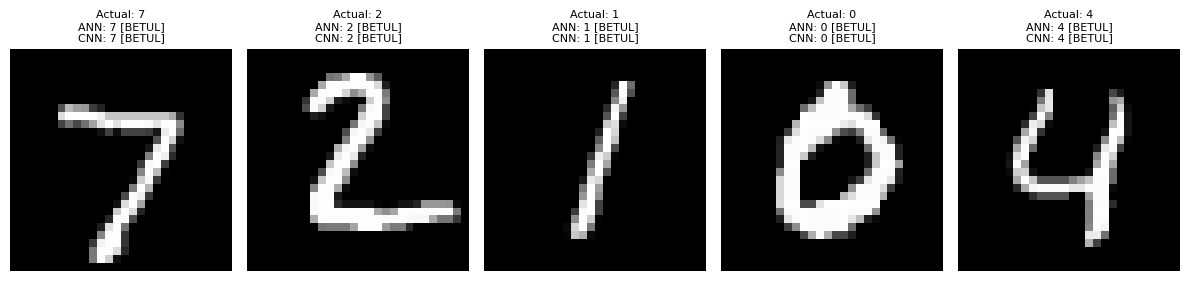

In [24]:
# 3.8.1 - Ambil 5 imej daripada testing dataset
n_show = 5
fig = plt.figure(figsize=(12, 4))

ann_model.eval()
cnn_model.eval()

with torch.no_grad():
    for i in range(n_show):
        image, actual_label = test_dataset[i]
        image_batch = image.unsqueeze(0).to(device)  # tambah dimensi batch: [1, 1, 28, 28]

        # 3.8.2 - Ramalan ANN
        output_ann = ann_model(image_batch)
        _, pred_ann = torch.max(output_ann, 1)
        pred_ann = pred_ann.item()

        # Ramalan CNN
        output_cnn = cnn_model(image_batch)
        _, pred_cnn = torch.max(output_cnn, 1)
        pred_cnn = pred_cnn.item()

        # 3.8.4 - Tanda betul/salah
        status_ann = "[BETUL]" if pred_ann == actual_label else "[SALAH]"
        status_cnn = "[BETUL]" if pred_cnn == actual_label else "[SALAH]"

        # 3.8.3 - Papar imej + label
        ax = fig.add_subplot(1, n_show, i + 1)
        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(f"Actual: {actual_label}\nANN: {pred_ann} {status_ann}\nCNN: {pred_cnn} {status_cnn}",
                     fontsize=8)
        ax.axis("off")

        print(f"Actual: {actual_label}")
        print(f"ANN Prediction: {pred_ann} {status_ann}")
        print(f"CNN Prediction: {pred_cnn} {status_cnn}")
        print("---")

plt.tight_layout()
plt.show()

# Langkah 9 — Bandingkan Keputusan ANN vs CNN

=== JADUAL PERBANDINGAN ===
MODEL     EPOCH     TESTING ACCURACY    RAMALAN BETUL/5
ANN       2         96.29               5/5
CNN       2         98.18               5/5


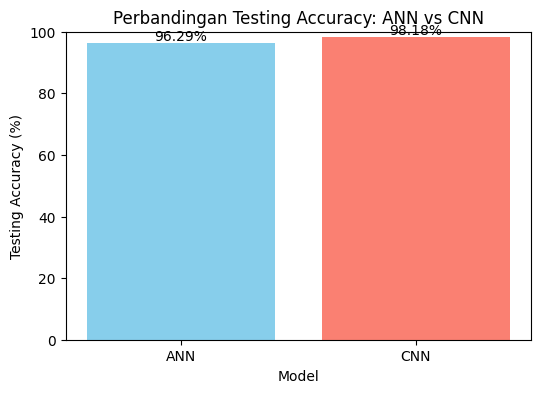


Model dengan testing accuracy lebih tinggi: CNN (98.18%)
Model dengan ramalan lebih tepat (5 imej): ANN dan CNN sama (5/5)


In [26]:
# 3.9.1 - Jadual perbandingan accuracy
print("=== JADUAL PERBANDINGAN ===")
print(f"{'MODEL':<10}{'EPOCH':<10}{'TESTING ACCURACY':<20}{'RAMALAN BETUL/5'}")
print(f"{'ANN':<10}{2:<10}{ann_accuracy:<20.2f}{betul_ann}/5")
print(f"{'CNN':<10}{2:<10}{cnn_accuracy:<20.2f}{betul_cnn}/5")

# 3.9.2 - Graf bar perbandingan
models = ['ANN', 'CNN']
accuracies = [ann_accuracy, cnn_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['skyblue', 'salmon'])
plt.title("Perbandingan Testing Accuracy: ANN vs CNN")
plt.xlabel("Model")
plt.ylabel("Testing Accuracy (%)")
plt.ylim(0, 100)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center')
plt.show()

# 3.9.3 - Model dengan testing accuracy lebih tinggi
if ann_accuracy > cnn_accuracy:
    print(f"\nModel dengan testing accuracy lebih tinggi: ANN ({ann_accuracy:.2f}%)")
elif cnn_accuracy > ann_accuracy:
    print(f"\nModel dengan testing accuracy lebih tinggi: CNN ({cnn_accuracy:.2f}%)")
else:
    print(f"\nKedua-dua model mempunyai testing accuracy yang sama ({ann_accuracy:.2f}%)")

# 3.9.4 - Model dengan ramalan 5 imej lebih banyak betul
if betul_ann > betul_cnn:
    print(f"Model dengan ramalan lebih tepat (5 imej): ANN ({betul_ann}/5)")
elif betul_cnn > betul_ann:
    print(f"Model dengan ramalan lebih tepat (5 imej): CNN ({betul_cnn}/5)")
else:
    print(f"Model dengan ramalan lebih tepat (5 imej): ANN dan CNN sama ({betul_ann}/5)")